In [1]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
D0 = "2005-01-03"
D1 = "2024-12-31"

rd = pd.read_parquet("../data/return/return_d.parquet").loc[D0:D1]
rf = pd.read_parquet("../data/return/ffr_d.parquet").reindex(rd.index)
rd.shape, rf.shape

((5033, 46), (5033, 1))

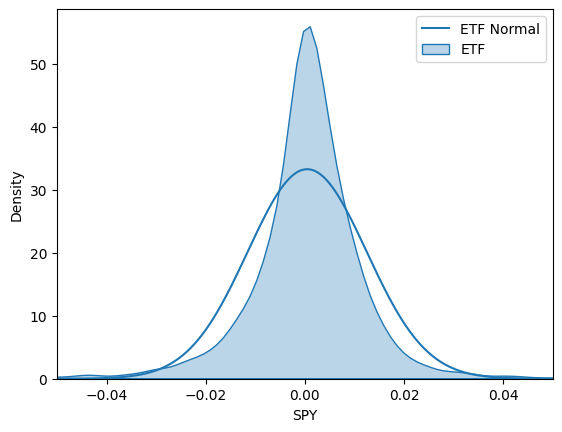

(np.float64(0.00046050723359838627), np.float64(0.01198982619810234))

In [3]:
D0_ = "2005-01-03"
D1_ = "2010-01-03"
D2_ = "2015-01-03"
D3_ = "2020-01-03"
D4_ = "2025-01-03"

etf = rd["SPY"].loc[D0_:D4_]
mu = etf.mean()
sigma = etf.std()

norm_pdf = lambda x: 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-0.5 * (x - mu)**2 / sigma**2)
x = np.linspace(etf.min(), etf.max(), 1000)

plt.plot(x, norm_pdf(x), label="ETF Normal")
sns.kdeplot(etf, label="ETF", fill=True, alpha=0.3)
plt.xlim(-0.05, 0.05)
plt.legend()
plt.show()
mu, sigma

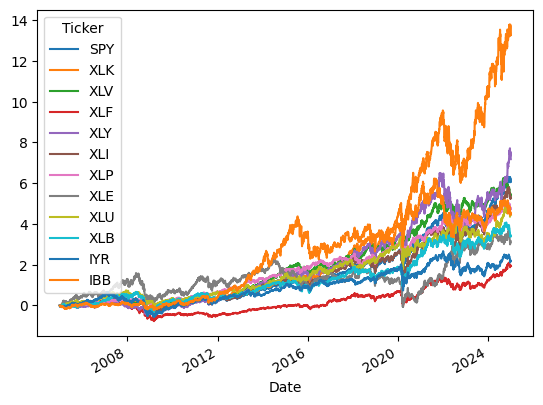

In [12]:
subset = rd[[
    "SPY",
    "XLK", "XLV", "XLF", "XLY", "XLI", "XLP", "XLE", "XLU", "XLB",
    "IYR", "IBB",
]].loc[D0:D1]
r_cumu = (subset+1.0).cumprod()-1.0
r_cumu.plot(legend=True)
plt.show()

In [5]:
# timeline = pd.date_range(start=D0, end=D1)
# day_of_wk = np.cos(2*np.pi / 7 * timeline.day_of_week)
# day_of_mt = np.cos(2*np.pi / 31 * timeline.day)
# day_of_yr = np.cos(2*np.pi / 365 * timeline.day_of_year)

In [6]:
def sharpe_geom(rd: pd.DataFrame, rf: pd.Series):
    assert rd.shape[0] == rf.shape[0]
    num_days = rd.notna().sum(axis=0)
    rd_ = rd.fillna(0.0)
    rf_ = rf.fillna(0.0).values
    ret_ann = ((rd_+1.0).prod() / (rf_+1.0).prod()) ** (252 / num_days) - 1.0
    vol_ann = rd_.std() * np.sqrt(252)
    return ret_ann / vol_ann

def annual_return(rd: pd.DataFrame) -> pd.Series:
    num_days = rd.notna().sum(axis=0)
    return (1.0+rd).prod() ** (252 / num_days)-1.0

def annual_volatility(rd: pd.DataFrame) -> pd.Series:
    return rd.std() * np.sqrt(252)

def total_return(rd: pd.DataFrame) -> pd.Series:
    return (1.0+rd).prod()-1.0


stats = pd.DataFrame({
    "sharpe": sharpe_geom(rd, rf),
    "ret ann": annual_return(rd),
    "vol ann": annual_volatility(rd),
    "ret tot": total_return(rd),
}, index=rd.columns)

stats.sort_values(by="sharpe", ascending=False)

,sharpe,ret ann,vol ann,ret tot
Ticker,,,,
BTC-USD,1.086222,0.528293,0.700947,21.093811
QQQ,0.585891,0.144971,0.215396,13.936734
XLK,0.559024,0.142343,0.221124,13.266691
XLP,0.520728,0.091304,0.140980,4.726170
XLV,0.476867,0.097317,0.166348,5.390294
XLC,0.468436,0.116994,0.231038,1.058144
SPY,0.445346,0.102845,0.190333,6.064994
XLY,0.424206,0.110948,0.218605,7.177202
GLD,0.407579,0.089382,0.175479,4.528082
